# Quiz 2: Gases

### What is the percent saturation of this water?

In [2]:
import math

# Given values
A_aq = 260.0        # Dissolved O2 in umol/kg
S = 35.5            # Salinity of water
T = 2.0             # Temperature in Celsius of water

# Constants for O2 
A0 = 5.80871
A1 = 3.20291
A2 = 4.17887
A3 = 5.10006
A4 = -9.87e-02
A5 = 3.80369
B0 = -7.02e-03
B1 = -7.70e-03
B2 = -1.14e-02
B3 = -9.52e-03
C0 = -2.76e-07


# Weiss equation form (ln solubility)
T_s = math.log((298.15 - T) / (273.15 + T))

ln_G = (
    A0 + A1 * T_s + A2 * (T_s ** 2) + A3 * (T_s ** 3) 
    + A4 * (T_s ** 4) + A5 * (T_s ** 5) 
    + S * (B0 + B1 * T_s + B2 * (T_s ** 2) + B3 * (T_s ** 3))
    + C0 * (S ** 2)
)

# Solubility in umol/kg
G = math.exp(ln_G)

# Percent saturation
percent_saturation = (A_aq / G) * 100.0

print(f"O2 solubility: {G:.2f} umol/kg")
print(f"Percent saturation: {percent_saturation:.1f}%")

O2 solubility: 329.29 umol/kg
Percent saturation: 79.0%


### Compute the Apparent Oxygen Utilisation (AOU) 

In [4]:
# Apparent Oxygen Utilisation (AOU)
AOU = G - A_aq

print(f"Apparent Oxygen Utilisation: {AOU:.2f} umol/kg")

Apparent Oxygen Utilisation: 69.29 umol/kg


### Convert oxygen concentration from units µmol/kg to mL/L
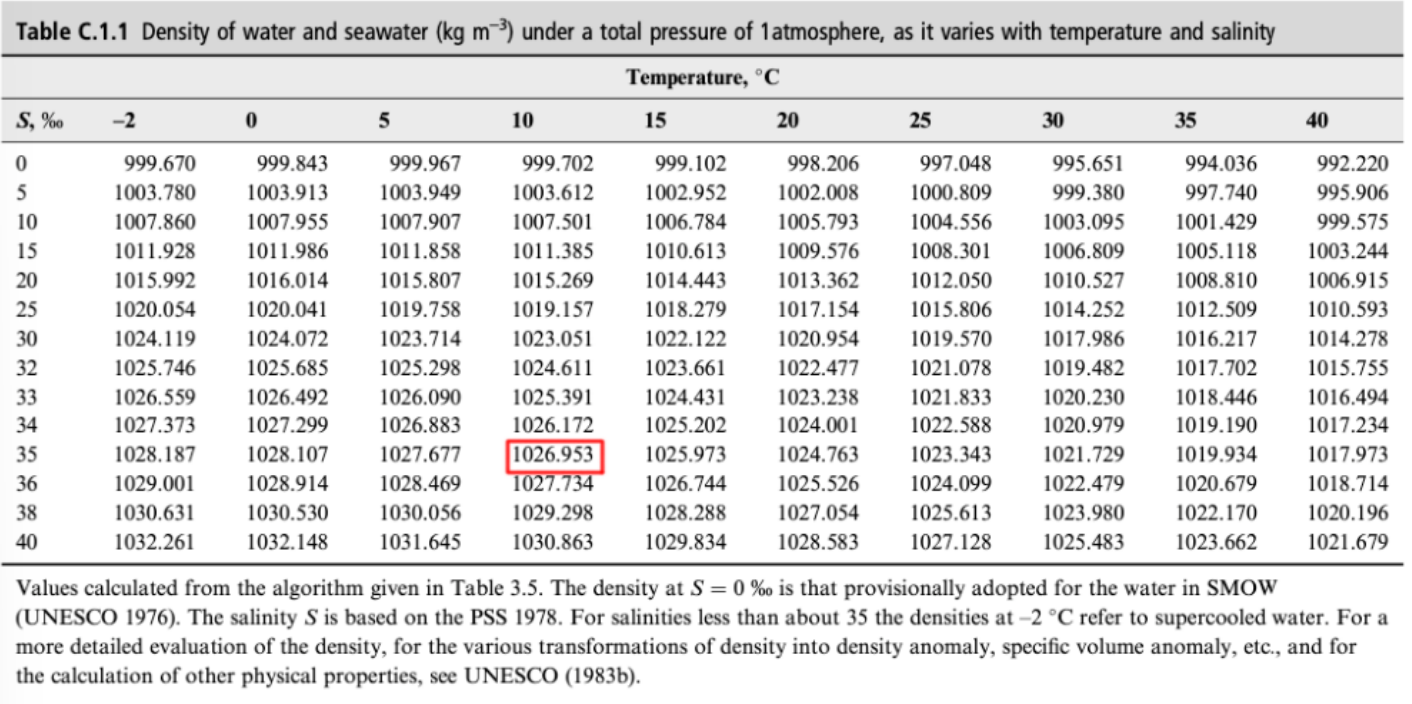

In [11]:
# Given values
A_aq = 200.0        # Dissolved O2 in umol/kg
S = 35.0            # Salinity of water
T = 10.0            # Temperature in Celsius of water

rho = 1026.953 / 1000 # kg/L (from table at S=35, T=10 C)

# Constants
UMOL_PER_ML_O2_STP = 2 * 22.3916  # umol per mL O2 gas at STP

# Convert
o2_umol_L = A_aq * rho
o2_mL_L = o2_umol_L / UMOL_PER_ML_O2_STP

print(f"O2 concentration: {o2_mL_L:.1f} mL/L")

O2 concentration: 4.6 mL/L


### What is the direction and intensity of the O2 flux when the wind speeds are approximately 5 m/s? 

You are on a cruise in the North Atlantic and you measure oxygen concentrations in surface waters and find that they are supersaturated by 10%. Surface water temperature is 15 C and Salinity is 35. The diffusion coefficient for O2 is 1.2 x 10-5 cm2 s-1. 

In [21]:
# Given
T = 15.0                 # degC                    - temperature
S = 35.0                 # practical salinity      - salinity
supersat = 0.10          # 10% supersaturation     - supersaturation relative to equilibrium
rho = 1026.0             # kg/m^3                  - density of water at 15 C and S=35                           
D_cm2_s = 1.2e-5         # cm^2/s                  - diffusivity of O2 in water at 15 C
delta_um = 60.0          # um                      - boundary layer thickness 


# Solubility at equilibrium (umol/kg)
T_s = math.log((298.15 - T) / (273.15 + T))
ln_G = (
    A0 + A1*T_s + A2*T_s**2 + A3*T_s**3 + A4*T_s**4 + A5*T_s**5
    + S*(B0 + B1*T_s + B2*T_s**2 + B3*T_s**3) + C0*S**2
)
G_umol_m3 = math.exp(ln_G) # umol/kg

# Convert Ceq to mol/m^3
G_mol_m3 = G_umol_m3 * rho * 1e-6 # mol/m^3

# Supersaturation concentration excess
deltaC_mol_m3 = supersat * G_mol_m3

# Gas transfer velocity k = D / delta
D_m2_s = D_cm2_s * 1e-4
delta_m = delta_um * 1e-6
k_m_s = D_m2_s / delta_m

# Flux (positive upward to atmosphere for supersaturation)
F_mol_m2_s = k_m_s * deltaC_mol_m3
F_umol_m2_s = F_mol_m2_s * 1e6
F_mmol_m2_day = F_mol_m2_s * 1000 * 86400
F_mol_m2_day = F_mol_m2_s * 86400

direction = "Ocean -> Atmosphere (degassing)" if F_mol_m2_s > 0 else "Atmosphere -> Ocean"

print(f"G (O2 solubility): {G_umol_m3:.2f} umol/kg")
print(f"k: {k_m_s:.2e} m/s")
print(f"Flux direction: {direction}")
print(f"Flux intensity: {F_umol_m2_s:.3f} umol m^-2 s^-1")
print(f"Flux intensity: {F_mmol_m2_day:.3f} mmol m^-2 day^-1")
print(f"Flux intensity: {F_mol_m2_day:.3f} mol m^-2 day^-1")

G (O2 solubility): 247.80 umol/kg
k: 2.00e-05 m/s
Flux direction: Ocean -> Atmosphere (degassing)
Flux intensity: 0.508 umol m^-2 s^-1
Flux intensity: 43.932 mmol m^-2 day^-1
Flux intensity: 0.044 mol m^-2 day^-1
